# Self-Supervised Learning

Self-supervised learning (SSL) is a paradigm where models learn rich representations from **unlabeled data** by solving pretext tasks whose supervisory signal is derived from the data itself. It bridges the gap between unsupervised and supervised learning, enabling powerful pre-training without expensive human annotations.

## Why Self-Supervised Learning?

- **Labeled data is scarce and expensive** annotation requires domain experts and significant time.
- **Unlabeled data is abundant** the internet contains billions of images, text documents, and audio clips.
- **SSL representations generalize** pre-trained encoders transfer well to downstream tasks with few labels.
- **Foundation models** (BERT, GPT, CLIP, DINO) are all built on SSL principles.

### The Core Idea

Given input $x$, create a pretext task that forces the model to learn semantically meaningful features:

$$\theta^* = \arg\min_\theta \mathcal{L}_{\text{pretext}}(f_\theta(x))$$

After pre-training, the encoder $f_\theta$ is used for downstream tasks via **linear probing** or **fine-tuning**.

### Taxonomy of SSL Methods

| Category | Methods |
|----------|--------|
| Contrastive | SimCLR, MoCo, BYOL, SimSiam |
| Non-contrastive / Redundancy Reduction | Barlow Twins, VICReg, WNCE |
| Clustering | SwAV, DeepCluster, SeLa |
| Masked Modeling | BERT, MAE, BEiT, data2vec, I-JEPA, iBOT |
| Distillation-based | DINO, DINOv2 |

## 1. Contrastive Learning

Contrastive methods learn representations by **pulling together** views of the same instance (positives) and **pushing apart** representations of different instances (negatives).

### Core Intuition

Given two augmented views $x_i$ and $x_j$ of the same image, their embeddings $z_i$ and $z_j$ should be similar. Embeddings of different images should be dissimilar.

### Data Augmentation Pipeline

Strong augmentations are critical:
- Random cropping + resizing
- Color jitter (brightness, contrast, saturation, hue)
- Gaussian blur
- Grayscale conversion
- Horizontal flipping

These augmentations ensure the model cannot use low-level shortcuts.

### 1.1 SimCLR A Simple Framework for Contrastive Learning

**SimCLR** (Chen et al., 2020) uses an **in-batch** negative sampling strategy. For a batch of $N$ images, each image produces 2 views, yielding $2N$ representations. For each positive pair $(i, j)$, all other $2(N-1)$ examples in the batch serve as negatives.

#### Architecture

$$x \xrightarrow{\text{aug}} \tilde{x}_i, \tilde{x}_j \xrightarrow{f(\cdot)} h_i, h_j \xrightarrow{g(\cdot)} z_i, z_j$$

- $f(\cdot)$: backbone encoder (ResNet)
- $g(\cdot)$: projection MLP head (discarded after pre-training)
- $z = g(f(x))$: normalized projection embeddings

#### NT-Xent Loss (Normalized Temperature-scaled Cross Entropy)

$$\ell_{i,j} = -\log \frac{\exp(\text{sim}(z_i, z_j)/\tau)}{\sum_{k \neq i} \exp(\text{sim}(z_i, z_k)/\tau)}$$

where $\text{sim}(u, v) = \frac{u^\top v}{\|u\| \|v\|}$ is the cosine similarity and $\tau$ is a temperature hyperparameter.

The final loss averages over all positive pairs:

$$\mathcal{L} = \frac{1}{2N} \sum_{k=1}^{N} \left[\ell(2k-1, 2k) + \ell(2k, 2k-1)\right]$$

#### Key Findings
- Larger batch sizes help (more negatives per positive)
- Projection head is crucial the representation at $h$ is better than at $z$
- Temperature $\tau = 0.07$ works well
- Stronger augmentations consistently improve performance

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset

print(f'PyTorch version: {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

PyTorch version: 2.12.1+cpu
Using device: cpu


In [2]:
class SimCLRAugmentation:
    """Produces two correlated views of the same image for SimCLR."""

    def __init__(self, size=32, s=1.0):
        color_jitter = transforms.ColorJitter(
            brightness=0.8 * s,
            contrast=0.8 * s,
            saturation=0.8 * s,
            hue=0.2 * s
        )
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(size=size, scale=(0.2, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomApply([color_jitter], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.GaussianBlur(kernel_size=int(0.1 * size) | 1, sigma=(0.1, 2.0)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                                 std=[0.2023, 0.1994, 0.2010])
        ])

    def __call__(self, x):
        return self.transform(x), self.transform(x)


print('SimCLR augmentation pipeline defined.')

SimCLR augmentation pipeline defined.


In [3]:
class ProjectionHead(nn.Module):
    """MLP projection head: z = g(h)."""

    def __init__(self, input_dim, hidden_dim=512, output_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


class SimCLR(nn.Module):
    """SimCLR: backbone encoder + projection head."""

    def __init__(self, backbone='resnet18', out_dim=128):
        super().__init__()
        encoder = models.resnet18(weights=None)
        feat_dim = encoder.fc.in_features
        # Remove the final classification layer
        encoder.fc = nn.Identity()
        self.encoder = encoder
        self.projector = ProjectionHead(feat_dim, hidden_dim=512, output_dim=out_dim)

    def forward(self, x):
        h = self.encoder(x)          # representation
        z = self.projector(h)        # projection
        z = F.normalize(z, dim=1)   # L2 normalize
        return h, z


model = SimCLR(backbone='resnet18', out_dim=128)
total_params = sum(p.numel() for p in model.parameters())
print(f'SimCLR total parameters: {total_params:,}')

SimCLR total parameters: 11,505,856


In [4]:
class NTXentLoss(nn.Module):
    """
    Normalized Temperature-scaled Cross Entropy Loss (NT-Xent).

    For a batch of 2N embeddings (N pairs), the loss for pair (i, j) is:
        l(i, j) = -log[ exp(sim(z_i, z_j) / tau) /
                        sum_{k != i} exp(sim(z_i, z_k) / tau) ]
    """

    def __init__(self, temperature=0.07):
        super().__init__()
        self.tau = temperature

    def forward(self, z1, z2):
        """
        Args:
            z1: (N, D) normalized embeddings of view 1
            z2: (N, D) normalized embeddings of view 2
        Returns:
            scalar NT-Xent loss
        """
        N = z1.size(0)
        # Concatenate all embeddings: [z1_0,...,z1_N, z2_0,...,z2_N]
        z = torch.cat([z1, z2], dim=0)  # (2N, D)

        # Compute full similarity matrix (2N x 2N)
        sim = torch.mm(z, z.t()) / self.tau  # (2N, 2N)

        # Mask out self-similarity (diagonal)
        mask_self = torch.eye(2 * N, dtype=torch.bool, device=z.device)
        sim.masked_fill_(mask_self, float('-inf'))

        # Positive pairs: (i, i+N) and (i+N, i)
        # Labels: for row i, the positive is at index i+N (mod 2N)
        labels = torch.cat([torch.arange(N, 2*N), torch.arange(0, N)]).to(z.device)

        loss = F.cross_entropy(sim, labels)
        return loss


# Quick sanity check
loss_fn = NTXentLoss(temperature=0.07)
z1 = F.normalize(torch.randn(32, 128), dim=1)
z2 = F.normalize(torch.randn(32, 128), dim=1)
loss = loss_fn(z1, z2)
print(f'NT-Xent loss (random embeddings): {loss.item():.4f}')

# Perfect case: z1 == z2
loss_perfect = loss_fn(z1, z1.clone())
print(f'NT-Xent loss (identical embeddings): {loss_perfect.item():.4f}')

NT-Xent loss (random embeddings): 4.7679
NT-Xent loss (identical embeddings): 0.0001


In [5]:
def simclr_train_step(model, optimizer, loss_fn, x1, x2, device):
    """Single SimCLR training step."""
    model.train()
    x1, x2 = x1.to(device), x2.to(device)

    _, z1 = model(x1)
    _, z2 = model(x2)

    loss = loss_fn(z1, z2)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


# Demonstrate with random tensors
model = SimCLR().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
loss_fn = NTXentLoss(temperature=0.07)

# Simulate a mini-batch
batch_size = 16
x1_dummy = torch.randn(batch_size, 3, 32, 32)
x2_dummy = torch.randn(batch_size, 3, 32, 32)

train_loss = simclr_train_step(model, optimizer, loss_fn, x1_dummy, x2_dummy, device)
print(f'Simulated SimCLR training step loss: {train_loss:.4f}')

Simulated SimCLR training step loss: 3.6777


### 1.2 MoCo Momentum Contrast

**MoCo** (He et al., 2020) addresses the limitation of SimCLR's large batch requirement by maintaining a **dynamic dictionary** (queue) of negative keys. This decouples the number of negatives from the batch size.

#### Two Key Components

**1. Queue** stores encoded keys from previous mini-batches. As new batches arrive, old keys are dequeued (FIFO). This gives access to a large and consistent set of negatives (e.g., 65,536) without requiring a huge batch.

**2. Momentum Encoder** a slowly-evolving copy of the query encoder whose weights are updated via exponential moving average (EMA):

$$\theta_k \leftarrow m\theta_k + (1-m)\theta_q$$

where $m \in [0, 1)$ is the momentum coefficient (typically $m = 0.999$). The momentum encoder is **not** updated by backpropagation this maintains consistency of the key representations in the queue.

#### InfoNCE / MoCo Loss

$$\mathcal{L}_q = -\log \frac{\exp(q \cdot k_+ / \tau)}{\exp(q \cdot k_+ / \tau) + \sum_{k^- \in \text{queue}} \exp(q \cdot k^- / \tau)}$$

#### MoCo v2 and v3 Improvements

- **MoCo v2**: Adds MLP projection head and stronger augmentations from SimCLR closes the gap with SimCLR without large batch sizes.
- **MoCo v3**: Replaces ResNet backbone with Vision Transformer (ViT), removes the queue (uses large batch directly), adds a stop-gradient prediction head.

In [6]:
class MoCo(nn.Module):
    """
    MoCo v2: Momentum Contrast with MLP projection head.
    Reference: He et al. (2020), Chen et al. (2020 MoCo v2)
    """

    def __init__(self, base_encoder=models.resnet18, dim=128, K=4096, m=0.999, T=0.07):
        """
        Args:
            dim:  feature dimension
            K:    queue size (number of negatives)
            m:    momentum for key encoder update
            T:    temperature for InfoNCE loss
        """
        super().__init__()
        self.K = K
        self.m = m
        self.T = T

        # Query encoder
        self.encoder_q = base_encoder(weights=None)
        feat_dim = self.encoder_q.fc.in_features
        self.encoder_q.fc = nn.Sequential(
            nn.Linear(feat_dim, feat_dim), nn.ReLU(), nn.Linear(feat_dim, dim)
        )

        # Key encoder (momentum copy)
        self.encoder_k = base_encoder(weights=None)
        self.encoder_k.fc = nn.Sequential(
            nn.Linear(feat_dim, feat_dim), nn.ReLU(), nn.Linear(feat_dim, dim)
        )

        # Initialize key encoder with query encoder weights
        for param_q, param_k in zip(self.encoder_q.parameters(),
                                     self.encoder_k.parameters()):
            param_k.data.copy_(param_q.data)
            param_k.requires_grad = False  # No gradient for key encoder

        # Create the queue
        self.register_buffer('queue', F.normalize(torch.randn(dim, K), dim=0))
        self.register_buffer('queue_ptr', torch.zeros(1, dtype=torch.long))

    @torch.no_grad()
    def _momentum_update_key_encoder(self):
        """EMA update: theta_k <- m * theta_k + (1-m) * theta_q"""
        for param_q, param_k in zip(self.encoder_q.parameters(),
                                     self.encoder_k.parameters()):
            param_k.data = param_k.data * self.m + param_q.data * (1.0 - self.m)

    @torch.no_grad()
    def _dequeue_and_enqueue(self, keys):
        """Update the queue: enqueue new keys, dequeue old ones."""
        batch_size = keys.shape[0]
        ptr = int(self.queue_ptr)
        # Replace oldest entries in the queue
        self.queue[:, ptr:ptr + batch_size] = keys.T
        ptr = (ptr + batch_size) % self.K
        self.queue_ptr[0] = ptr

    def forward(self, im_q, im_k):
        """Compute MoCo loss for query/key image pairs."""
        # Compute query features
        q = F.normalize(self.encoder_q(im_q), dim=1)  # (N, dim)

        # Compute key features (no gradient)
        with torch.no_grad():
            self._momentum_update_key_encoder()
            k = F.normalize(self.encoder_k(im_k), dim=1)  # (N, dim)

        # Positive logits: (N, 1)
        l_pos = torch.einsum('nc,nc->n', [q, k]).unsqueeze(-1)

        # Negative logits: (N, K)
        l_neg = torch.einsum('nc,ck->nk', [q, self.queue.clone().detach()])

        # Logits: (N, 1+K)
        logits = torch.cat([l_pos, l_neg], dim=1) / self.T

        # Labels: positives are index 0
        labels = torch.zeros(logits.shape[0], dtype=torch.long, device=logits.device)

        loss = F.cross_entropy(logits, labels)

        # Update queue
        self._dequeue_and_enqueue(k)

        return loss


# Instantiate and test
moco = MoCo(dim=128, K=512, m=0.999, T=0.07).to(device)
im_q = torch.randn(8, 3, 32, 32).to(device)
im_k = torch.randn(8, 3, 32, 32).to(device)
loss = moco(im_q, im_k)
print(f'MoCo loss: {loss.item():.4f}')
print(f'Queue shape: {moco.queue.shape}')

MoCo loss: 0.5086
Queue shape: torch.Size([128, 512])


### 1.3 BYOL and SimSiam Self-Distillation Without Negatives

A surprising discovery: negatives are not required for contrastive learning to avoid collapse!

#### BYOL (Bootstrap Your Own Latent)

**BYOL** (Grill et al., 2020) uses two networks:
- **Online network**: encoder $f_\theta$ + projector $g_\theta$ + predictor $q_\theta$
- **Target network**: encoder $f_\xi$ + projector $g_\xi$ (EMA of online, no predictor)

The loss minimizes the negative cosine similarity between online prediction and target projection:

$$\mathcal{L}_{\text{BYOL}} = -\frac{q_\theta(z_\theta)}{\|q_\theta(z_\theta)\|} \cdot \frac{z_\xi}{\|z_\xi\|}$$

Target weights are updated via EMA: $\xi \leftarrow \tau \xi + (1-\tau)\theta$

**Why no collapse?** The EMA target provides a slowly changing, stable target. The predictor adapts to correct for distribution shift.

#### SimSiam (Simple Siamese Networks)

**SimSiam** (Chen & He, 2021) simplifies BYOL further no momentum encoder, no negatives, just a **stop-gradient** operation:

$$\mathcal{L}_{\text{SimSiam}} = -\frac{1}{2}\left[\frac{p_1}{\|p_1\|} \cdot \text{stopgrad}\left(\frac{z_2}{\|z_2\|}\right) + \frac{p_2}{\|p_2\|} \cdot \text{stopgrad}\left(\frac{z_1}{\|z_1\|}\right)\right]$$

The stop-gradient is essential without it, the trivial solution (all zeros) minimizes the loss.

In [7]:
class SimSiam(nn.Module):
    """
    SimSiam: Exploring Simple Siamese Representation Learning.
    Chen & He, 2021. Stop-gradient prevents collapse without negatives.
    """

    def __init__(self, backbone_dim=512, proj_dim=2048, pred_dim=512):
        super().__init__()
        encoder = models.resnet18(weights=None)
        encoder.fc = nn.Identity()
        self.encoder = encoder

        # Projection MLP (3-layer)
        self.projector = nn.Sequential(
            nn.Linear(backbone_dim, proj_dim, bias=False),
            nn.BatchNorm1d(proj_dim),
            nn.ReLU(inplace=True),
            nn.Linear(proj_dim, proj_dim, bias=False),
            nn.BatchNorm1d(proj_dim),
            nn.ReLU(inplace=True),
            nn.Linear(proj_dim, proj_dim, bias=False),
            nn.BatchNorm1d(proj_dim, affine=False)
        )

        # Prediction MLP (2-layer bottleneck)
        self.predictor = nn.Sequential(
            nn.Linear(proj_dim, pred_dim, bias=False),
            nn.BatchNorm1d(pred_dim),
            nn.ReLU(inplace=True),
            nn.Linear(pred_dim, proj_dim)
        )

    def forward(self, x1, x2):
        # Encode and project both views
        z1 = self.projector(self.encoder(x1))
        z2 = self.projector(self.encoder(x2))

        # Predict (asymmetric)
        p1 = self.predictor(z1)
        p2 = self.predictor(z2)

        # Stop-gradient on targets
        loss = self._neg_cosine(p1, z2.detach()) / 2 + \
               self._neg_cosine(p2, z1.detach()) / 2
        return loss

    @staticmethod
    def _neg_cosine(p, z):
        """Negative cosine similarity."""
        p = F.normalize(p, dim=1)
        z = F.normalize(z, dim=1)
        return -(p * z).sum(dim=1).mean()


simsiam = SimSiam().to(device)
x1 = torch.randn(8, 3, 32, 32).to(device)
x2 = torch.randn(8, 3, 32, 32).to(device)
loss = simsiam(x1, x2)
print(f'SimSiam loss: {loss.item():.4f} (should be around -1.0 to 1.0)')

SimSiam loss: -0.0043 (should be around -1.0 to 1.0)


## 2. Non-Contrastive / Redundancy Reduction Methods

These methods avoid collapse through **information-theoretic** objectives rather than negative pairs.

### 2.1 Barlow Twins

**Barlow Twins** (Zbontar et al., 2021) borrows the **redundancy reduction principle** from neuroscience (Barlow, 1961). The objective decorrelates the components of the embedding vectors.

Given two embeddings $Z^A$ and $Z^B$ (batch-normalized), the **cross-correlation matrix** is:

$$C_{ij} = \frac{\sum_b z^A_{b,i} z^B_{b,j}}{\sqrt{\sum_b (z^A_{b,i})^2} \sqrt{\sum_b (z^B_{b,j})^2}}$$

The loss pushes $C$ toward the identity matrix:

$$\mathcal{L} = \sum_i (1 - C_{ii})^2 + \lambda \sum_{i \neq j} C_{ij}^2$$

- **Invariance term** $\sum_i (1 - C_{ii})^2$: diagonal elements should be 1 (same feature in both views).
- **Redundancy reduction term** $\lambda \sum_{i \neq j} C_{ij}^2$: off-diagonal elements should be 0 (decorrelated features).

### 2.2 VICReg

**VICReg** (Bardes et al., 2022) uses three explicit regularization terms:

$$\mathcal{L}_{\text{VICReg}} = \lambda \cdot s(Z, Z') + \mu \cdot [v(Z) + v(Z')] + \nu \cdot [c(Z) + c(Z')]$$

- $s$: **invariance** MSE between embeddings of two views
- $v$: **variance** hinge loss to maintain variance above a threshold
- $c$: **covariance** decorrelation of different dimensions

### 2.3 WNCE

**WNCE** (Weighted Noise-Contrastive Estimation) reweights negatives by their semantic similarity, assigning lower weight to samples that are semantically close to the positive, reducing false negatives.

In [8]:
class BarlowTwinsLoss(nn.Module):
    """
    Barlow Twins loss: pushes the cross-correlation matrix toward identity.
    Zbontar et al., 2021.
    """

    def __init__(self, lambda_coeff=5e-3):
        super().__init__()
        self.lambda_coeff = lambda_coeff

    def forward(self, z_a, z_b):
        """
        Args:
            z_a, z_b: (N, D) unnormalized projections from two views
        """
        N, D = z_a.shape

        # Batch-normalize along batch dimension
        z_a = (z_a - z_a.mean(dim=0)) / (z_a.std(dim=0) + 1e-5)
        z_b = (z_b - z_b.mean(dim=0)) / (z_b.std(dim=0) + 1e-5)

        # Cross-correlation matrix C: (D, D)
        C = torch.mm(z_a.T, z_b) / N

        # Invariance term: (diagonal - 1)^2
        on_diag = torch.diagonal(C).add_(-1).pow_(2).sum()

        # Redundancy reduction term: off-diagonal elements^2
        off_diag = self._off_diagonal(C).pow_(2).sum()

        loss = on_diag + self.lambda_coeff * off_diag
        return loss

    @staticmethod
    def _off_diagonal(x):
        """Return a flattened view of off-diagonal elements."""
        n, m = x.shape
        assert n == m
        return x.flatten()[:-1].view(n - 1, n + 1)[:, 1:].flatten()


bt_loss = BarlowTwinsLoss(lambda_coeff=5e-3)
za = torch.randn(16, 256)
zb = torch.randn(16, 256)
loss = bt_loss(za, zb)
print(f'Barlow Twins loss (random): {loss.item():.4f}')

# With identical embeddings, only off-diagonal terms remain
loss_same = bt_loss(za, za.clone())
print(f'Barlow Twins loss (same view): {loss_same.item():.4f}')

Barlow Twins loss (random): 291.8808
Barlow Twins loss (same view): 20.1147


## 3. Clustering-Based SSL Methods

Clustering methods assign pseudo-labels to images via online clustering, then train the encoder to predict these assignments.

### 3.1 DeepCluster

**DeepCluster** (Caron et al., 2018) alternates between:
1. **Clustering** run k-means on current features to assign pseudo-labels
2. **Training** train the network with cross-entropy loss on pseudo-labels

Drawback: expensive offline clustering step, unstable early training.

### 3.2 SeLa (Self-Labeling)

**SeLa** (Asano et al., 2020) casts label assignment as an **optimal transport** problem, ensuring uniform assignment (no collapsed clusters). Uses Sinkhorn-Knopp iterations.

### 3.3 SwAV (Swapping Assignments between Views)

**SwAV** (Caron et al., 2020) performs **online** clustering by:
1. Projecting embeddings onto a set of learned **prototypes** $C = \{c_1, ..., c_K\}$
2. Computing soft cluster assignments via Sinkhorn-Knopp
3. Enforcing **swapped prediction**: predict assignment of view 1 using features of view 2

$$\mathcal{L}(z_t, z_s) = -\sum_k q_t^{(k)} \log p_s^{(k)}$$

where $q_t$ is the assignment of view $t$ and $p_s$ is the predicted assignment from features of view $s$.

SwAV also introduces **multi-crop**: additional small crops at lower resolution to increase the number of views efficiently.

In [9]:
def sinkhorn_knopp(Q, n_iterations=3, epsilon=0.05):
    """
    Sinkhorn-Knopp algorithm for soft cluster assignment (equipartition).
    Ensures balanced assignment: each prototype gets the same total weight.

    Args:
        Q: (K, N) similarity matrix (prototypes x batch)
        n_iterations: number of SK iterations
        epsilon: sharpening temperature
    Returns:
        Q: (K, N) normalized assignment matrix
    """
    Q = torch.exp(Q / epsilon).T  # (N, K)
    K, N = Q.shape[1], Q.shape[0]

    # Make rows and columns sum to 1/N and 1/K
    for _ in range(n_iterations):
        Q /= Q.sum(dim=0, keepdim=True)  # normalize columns (over batch)
        Q /= K
        Q /= Q.sum(dim=1, keepdim=True)  # normalize rows (over prototypes)
        Q /= N

    Q *= N  # scale to make each row sum to 1
    return Q.T  # (K, N)


# Example: 8 prototypes, batch of 16 samples
scores = torch.randn(8, 16)  # raw dot products with prototypes
assignments = sinkhorn_knopp(scores)
print(f'Assignment shape: {assignments.shape}')
print(f'Row sums (each prototype): {assignments.sum(dim=1)}')
print(f'Col sums (each sample should sum to 1 after transpose): {assignments.sum(dim=0).mean():.3f}')

Assignment shape: torch.Size([8, 16])
Row sums (each prototype): tensor([2.3505, 1.9186, 1.2080, 2.6430, 2.9007, 3.1681, 1.0001, 0.8109])
Col sums (each sample should sum to 1 after transpose): 1.000


## 4. Masked Modeling

Masked modeling is inspired by **cloze tests** in NLP hide part of the input and predict it. This forces the model to understand context and structure.

### 4.1 BERT Masking (NLP)

**BERT** (Devlin et al., 2018) masks 15% of input tokens randomly:
- 80% replaced with `[MASK]`
- 10% replaced with a random token
- 10% kept unchanged

The model predicts the original token at masked positions:

$$\mathcal{L}_{\text{MLM}} = -\sum_{i \in \mathcal{M}} \log P(x_i | x_{\setminus \mathcal{M}})$$

### 4.2 MAE Masked Autoencoders

**MAE** (He et al., 2022) extends masked modeling to images using a Vision Transformer:

1. **Patch tokenization**: divide image into $P \times P$ patches (e.g., $16 \times 16$)
2. **High masking ratio**: randomly mask 75% of patches
3. **Asymmetric encoder-decoder**:
   - **Encoder**: only processes visible (unmasked) patches computationally efficient
   - **Decoder**: lightweight, processes all tokens (encoded + mask tokens)
4. **Reconstruction target**: normalized pixel values of masked patches

$$\mathcal{L}_{\text{MAE}} = \frac{1}{|\mathcal{M}|} \sum_{i \in \mathcal{M}} \|\hat{x}_i - x_i\|_2^2$$

**Key insight**: High masking ratio (75%) creates a challenging task that forces learning of holistic representations, not just texture statistics.

### 4.3 BEiT

**BEiT** (Bao et al., 2022) predicts discrete visual tokens (from a dVAE tokenizer) rather than raw pixels, analogous to BERT predicting discrete word IDs.

### 4.4 data2vec

**data2vec** (Baevski et al., 2022) unifies masked modeling across modalities (text, images, audio) by predicting **latent representations** of the full input (from an EMA teacher) rather than raw inputs.

### 4.5 I-JEPA

**I-JEPA** (Assran et al., 2023) predicts representations of multiple **target blocks** within an image from a single context block, entirely in latent space (no pixel reconstruction).

### 4.6 iBOT

**iBOT** (Zhou et al., 2021) combines DINO's self-distillation with masked image modeling, predicting both global and local (patch-level) representations.

In [10]:
class PatchEmbed(nn.Module):
    """Split image into non-overlapping patches and embed them."""

    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: (B, C, H, W) -> (B, N, embed_dim)
        x = self.proj(x)         # (B, embed_dim, H/P, W/P)
        x = x.flatten(2)         # (B, embed_dim, N)
        x = x.transpose(1, 2)   # (B, N, embed_dim)
        return x


class MAEEncoder(nn.Module):
    """
    Simplified MAE Encoder: processes only visible (unmasked) patches.
    Uses a shallow Transformer for demonstration.
    """

    def __init__(self, img_size=64, patch_size=8, embed_dim=256, depth=4,
                 num_heads=8, mask_ratio=0.75):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, embed_dim=embed_dim)
        self.num_patches = self.patch_embed.num_patches
        self.mask_ratio = mask_ratio
        self.embed_dim = embed_dim

        # Learnable positional embeddings
        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.num_patches, embed_dim)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * 4, dropout=0.0,
            batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def random_masking(self, x):
        """
        Random masking: keep (1 - mask_ratio) patches.
        Returns visible patches and the mask/restore indices.
        """
        B, N, D = x.shape
        len_keep = int(N * (1 - self.mask_ratio))

        # Random permutation of patch indices
        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        # Keep only the first len_keep indices
        ids_keep = ids_shuffle[:, :len_keep]

        # Gather visible patches
        x_masked = torch.gather(
            x, dim=1,
            index=ids_keep.unsqueeze(-1).expand(-1, -1, D)
        )

        # Create binary mask: 0 = visible, 1 = masked
        mask = torch.ones(B, N, device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)

        return x_masked, mask, ids_restore

    def forward(self, x):
        # Embed patches
        x = self.patch_embed(x)              # (B, N, D)
        x = x + self.pos_embed               # add positional embeddings

        # Mask: keep only visible patches
        x, mask, ids_restore = self.random_masking(x)

        # Encode visible patches
        x = self.transformer(x)
        x = self.norm(x)

        return x, mask, ids_restore


class MAEDecoder(nn.Module):
    """
    Lightweight MAE Decoder: reconstructs all patches (visible + masked).
    """

    def __init__(self, num_patches, encoder_dim=256, decoder_dim=128,
                 patch_size=8, depth=2, num_heads=4, in_chans=3):
        super().__init__()
        self.num_patches = num_patches
        self.patch_size = patch_size
        self.decoder_embed = nn.Linear(encoder_dim, decoder_dim)

        # Learnable mask token
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))

        self.decoder_pos_embed = nn.Parameter(
            torch.zeros(1, num_patches, decoder_dim)
        )

        decoder_layer = nn.TransformerEncoderLayer(
            d_model=decoder_dim, nhead=num_heads,
            dim_feedforward=decoder_dim * 4, dropout=0.0,
            batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(decoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(decoder_dim)

        # Predict pixel values for each patch
        self.pred = nn.Linear(decoder_dim, patch_size * patch_size * in_chans)

        nn.init.trunc_normal_(self.mask_token, std=0.02)
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)

    def forward(self, x, ids_restore):
        B, N_vis, _ = x.shape

        # Project encoder dim -> decoder dim
        x = self.decoder_embed(x)

        # Append mask tokens for missing positions
        N_total = ids_restore.shape[1]
        N_mask = N_total - N_vis
        mask_tokens = self.mask_token.expand(B, N_mask, -1)
        x = torch.cat([x, mask_tokens], dim=1)  # (B, N_total, D)

        # Un-shuffle to original patch order
        x = torch.gather(
            x, dim=1,
            index=ids_restore.unsqueeze(-1).expand(-1, -1, x.shape[-1])
        )

        # Add positional embeddings and decode
        x = x + self.decoder_pos_embed
        x = self.transformer(x)
        x = self.norm(x)

        # Predict pixel values: (B, N, patch_size^2 * 3)
        x = self.pred(x)
        return x


print('MAE Encoder and Decoder classes defined.')

MAE Encoder and Decoder classes defined.


In [11]:
class MAE(nn.Module):
    """Full MAE model: encode visible patches, decode all patches, compute loss."""

    def __init__(self, img_size=64, patch_size=8, in_chans=3,
                 encoder_dim=256, decoder_dim=128,
                 encoder_depth=4, decoder_depth=2,
                 num_heads=8, mask_ratio=0.75):
        super().__init__()
        num_patches = (img_size // patch_size) ** 2

        self.encoder = MAEEncoder(
            img_size=img_size, patch_size=patch_size,
            embed_dim=encoder_dim, depth=encoder_depth,
            num_heads=num_heads, mask_ratio=mask_ratio
        )
        self.decoder = MAEDecoder(
            num_patches=num_patches, encoder_dim=encoder_dim,
            decoder_dim=decoder_dim, patch_size=patch_size,
            depth=decoder_depth, num_heads=4, in_chans=in_chans
        )
        self.patch_size = patch_size
        self.in_chans = in_chans

    def patchify(self, imgs):
        """Convert image to patches: (B, C, H, W) -> (B, N, patch_size^2*C)"""
        p = self.patch_size
        B, C, H, W = imgs.shape
        h, w = H // p, W // p
        x = imgs.reshape(B, C, h, p, w, p)
        x = x.permute(0, 2, 4, 3, 5, 1)   # (B, h, w, p, p, C)
        x = x.reshape(B, h * w, p * p * C)
        return x

    def forward(self, imgs):
        # Encode
        latent, mask, ids_restore = self.encoder(imgs)

        # Decode
        pred = self.decoder(latent, ids_restore)  # (B, N, patch_size^2*3)

        # Compute loss only on masked patches
        target = self.patchify(imgs)  # (B, N, patch_size^2*3)

        # Normalize target per patch (as in original MAE)
        mean = target.mean(dim=-1, keepdim=True)
        var = target.var(dim=-1, keepdim=True)
        target = (target - mean) / (var + 1e-6).sqrt()

        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)          # (B, N) mean over patch pixels
        loss = (loss * mask).sum() / mask.sum()  # mean over masked patches

        return loss, pred, mask


# Instantiate and test
mae = MAE(img_size=64, patch_size=8, encoder_dim=256, decoder_dim=128).to(device)
imgs = torch.randn(4, 3, 64, 64).to(device)
loss, pred, mask = mae(imgs)

print(f'MAE reconstruction loss: {loss.item():.4f}')
print(f'Number of patches: {mae.encoder.num_patches}')
print(f'Masked patches per image: {mask[0].sum().item():.0f}/{mae.encoder.num_patches}')
print(f'Prediction shape: {pred.shape}')

total = sum(p.numel() for p in mae.parameters())
print(f'MAE total parameters: {total:,}')

MAE reconstruction loss: 1.4082
Number of patches: 64
Masked patches per image: 48/64
Prediction shape: torch.Size([4, 64, 192])
MAE total parameters: 3,688,128


/tmp/ipykernel_59958/1479374540.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
/tmp/ipykernel_59958/1479374540.py:116: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(decoder_layer, num_layers=depth)


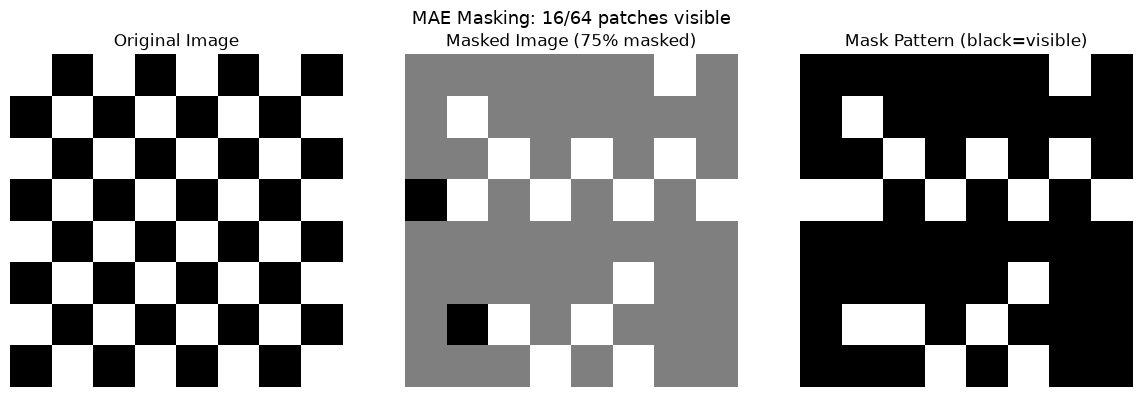

Visible patches: 16, Masked patches: 48


In [12]:
def visualize_mae_masking(img_size=64, patch_size=8, mask_ratio=0.75, seed=42):
    """Visualize MAE masking pattern on a synthetic checkerboard image."""
    torch.manual_seed(seed)

    # Create a synthetic checkerboard pattern
    img = torch.zeros(3, img_size, img_size)
    for i in range(0, img_size, patch_size * 2):
        for j in range(0, img_size, patch_size * 2):
            img[:, i:i+patch_size, j:j+patch_size] = 1.0
            if i + patch_size < img_size and j + patch_size < img_size:
                img[:, i+patch_size:i+2*patch_size, j+patch_size:j+2*patch_size] = 1.0

    num_patches = (img_size // patch_size) ** 2
    n_patches_per_row = img_size // patch_size
    len_keep = int(num_patches * (1 - mask_ratio))

    # Random mask
    noise = torch.rand(num_patches)
    ids_shuffle = torch.argsort(noise)
    mask = torch.ones(num_patches)
    mask[ids_shuffle[:len_keep]] = 0
    mask_2d = mask.reshape(n_patches_per_row, n_patches_per_row)

    # Apply mask to image
    img_masked = img.clone()
    for p_idx in range(num_patches):
        if mask[p_idx] == 1:
            row = (p_idx // n_patches_per_row) * patch_size
            col = (p_idx % n_patches_per_row) * patch_size
            img_masked[:, row:row+patch_size, col:col+patch_size] = 0.5  # gray

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img.permute(1, 2, 0).numpy())
    axes[0].set_title('Original Image', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(img_masked.permute(1, 2, 0).numpy())
    axes[1].set_title(f'Masked Image ({mask_ratio*100:.0f}% masked)', fontsize=12)
    axes[1].axis('off')

    axes[2].imshow(mask_2d.numpy(), cmap='gray_r', vmin=0, vmax=1)
    axes[2].set_title('Mask Pattern (black=visible)', fontsize=12)
    axes[2].axis('off')

    plt.suptitle(f'MAE Masking: {len_keep}/{num_patches} patches visible', fontsize=13)
    plt.tight_layout()
    plt.savefig('/tmp/mae_masking.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Visible patches: {len_keep}, Masked patches: {num_patches - len_keep}')


visualize_mae_masking()

## 5. Distillation-Based SSL: DINO and DINOv2

### 5.1 DINO Self-Distillation with No Labels

**DINO** (Caron et al., 2021) frames SSL as self-distillation: a **student** network learns to match the output distribution of a **teacher** network, where the teacher is an EMA of the student.

#### Architecture

Both student and teacher share the same architecture (ViT or ResNet) with a projection head followed by a softmax over $K$ dimensions (prototype assignments).

#### Multi-Crop Strategy

- **Global views** $x_1, x_2$: large crops (224×224), processed by both student and teacher
- **Local views** $x_3, ..., x_V$: small crops (~96×96), processed by student only

#### Loss

The cross-entropy between teacher and student softmax outputs:

$$\mathcal{L} = -\sum_{x \in \{x_g\}} P_t(x) \log P_s(x')$$

where $P_t, P_s$ are sharpened softmax distributions:

$$P_t(x)^{(k)} = \frac{\exp((g_t(x)^{(k)} - c) / \tau_t)}{\sum_{k'} \exp((g_t(x)^{(k')} - c) / \tau_t)}$$

**Centering** $c$ is updated as an EMA of batch means, preventing collapse.

#### Remarkable DINO Properties
- ViT attention heads **automatically discover object segmentation** without any supervision
- Linear probe on frozen features achieves strong results on ImageNet
- The CLS token learns powerful semantic features

### 5.2 DINOv2

**DINOv2** (Oquab et al., 2023) improves upon DINO by:
- **Curated training data**: 142M images filtered for quality via self-supervised similarity
- **Combined DINO + iBOT** objectives (global + patch-level distillation)
- **Sinkhorn-Knopp centering** (replaces simple mean centering)
- **KoLeo regularizer** to encourage uniform feature distribution
- Scales to ViT-g (1B parameters) provides excellent off-the-shelf features

In [13]:
class DINOHead(nn.Module):
    """
    DINO projection head: MLP + L2 normalization + weight-normalized linear layer.
    """

    def __init__(self, in_dim, out_dim=65536, hidden_dim=2048, bottleneck_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, bottleneck_dim)
        )
        # Weight-normalized last layer (no bias)
        self.last_layer = nn.utils.weight_norm(
            nn.Linear(bottleneck_dim, out_dim, bias=False)
        )
        self.last_layer.weight_g.data.fill_(1)
        self.last_layer.weight_g.requires_grad = False

    def forward(self, x):
        x = self.mlp(x)
        x = F.normalize(x, dim=-1)  # L2 normalize
        x = self.last_layer(x)
        return x


class DINOLoss(nn.Module):
    """
    DINO self-distillation loss with centering and sharpening.
    """

    def __init__(self, out_dim, n_crops=8, warmup_teacher_temp=0.04,
                 teacher_temp=0.04, warmup_epochs=30, nepochs=100,
                 student_temp=0.1, center_momentum=0.9):
        super().__init__()
        self.student_temp = student_temp
        self.center_momentum = center_momentum
        self.n_crops = n_crops
        self.register_buffer('center', torch.zeros(1, out_dim))
        # Teacher temperature schedule
        self.teacher_temp = teacher_temp

    def forward(self, student_output, teacher_output):
        """
        Args:
            student_output: list of (B, out_dim) tensors (all crops)
            teacher_output: list of (B, out_dim) tensors (global crops only)
        """
        student_out = student_output / self.student_temp
        student_out = student_out.chunk(self.n_crops)

        # Sharpen and center teacher output
        temp = self.teacher_temp
        teacher_out = F.softmax((teacher_output - self.center) / temp, dim=-1)
        teacher_out = teacher_out.detach().chunk(2)  # 2 global views

        total_loss = 0
        n_loss_terms = 0

        for iq, q in enumerate(teacher_out):
            for iv, v in enumerate(student_out):
                if iv == iq:
                    continue  # skip same view
                loss = torch.sum(-q * F.log_softmax(v, dim=-1), dim=-1)
                total_loss += loss.mean()
                n_loss_terms += 1

        total_loss /= n_loss_terms
        self.update_center(teacher_output)
        return total_loss

    @torch.no_grad()
    def update_center(self, teacher_output):
        """EMA update of centering vector."""
        batch_center = teacher_output.mean(dim=0, keepdim=True)
        self.center = self.center * self.center_momentum + \
                      batch_center * (1 - self.center_momentum)


# Quick instantiation test
dino_head = DINOHead(in_dim=512, out_dim=1024)
x = torch.randn(8, 512)
out = dino_head(x)
print(f'DINO head output shape: {out.shape}')

dino_loss_fn = DINOLoss(out_dim=1024, n_crops=4)
student_out = torch.randn(32, 1024)  # 4 crops * 8 batch
teacher_out = torch.randn(16, 1024)  # 2 global crops * 8 batch
loss = dino_loss_fn(student_out, teacher_out)
print(f'DINO loss: {loss.item():.4f}')

DINO head output shape: torch.Size([8, 1024])
DINO loss: 34.1565


/home/dell/Desktop/AI_Tasks/Additional_Data/AI/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


### Using DINOv2 from HuggingFace

DINOv2 pre-trained models are available via HuggingFace Transformers.

In [14]:
# DINOv2 feature extraction via HuggingFace
# Uncomment to run (requires transformers and internet access)

# from transformers import AutoImageProcessor, AutoModel
# from PIL import Image
# import requests

# model_name = 'facebook/dinov2-small'  # Options: dinov2-small/base/large/giant
# processor = AutoImageProcessor.from_pretrained(model_name)
# dino_model = AutoModel.from_pretrained(model_name)
# dino_model.eval()

# # Load a sample image
# url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
# image = Image.open(requests.get(url, stream=True).raw)

# # Preprocess and extract features
# inputs = processor(images=image, return_tensors='pt')
# with torch.no_grad():
#     outputs = dino_model(**inputs)

# # CLS token embedding (global image representation)
# cls_embedding = outputs.last_hidden_state[:, 0, :]
# print(f'DINOv2 CLS embedding shape: {cls_embedding.shape}')

# # Patch embeddings (spatial features)
# patch_embeddings = outputs.last_hidden_state[:, 1:, :]
# print(f'Patch embeddings shape: {patch_embeddings.shape}')

print('DINOv2 HuggingFace code ready (commented out to avoid download).')
print('Uncomment and run to use facebook/dinov2-small model.')
print()
print('Available DINOv2 variants:')
for v in ['dinov2-small', 'dinov2-base', 'dinov2-large', 'dinov2-giant']:
    print(f'  facebook/{v}')

DINOv2 HuggingFace code ready (commented out to avoid download).
Uncomment and run to use facebook/dinov2-small model.

Available DINOv2 variants:
  facebook/dinov2-small
  facebook/dinov2-base
  facebook/dinov2-large
  facebook/dinov2-giant


## 6. Downstream Evaluation: Linear Probing vs Fine-Tuning

After pre-training a self-supervised encoder, two main evaluation protocols are used:

### 6.1 Linear Probing

Freeze the entire pre-trained encoder and train **only a linear classifier** on top:

$$\hat{y} = \text{softmax}(W \cdot f_\theta(x) + b)$$

- **Pros**: Directly measures the quality of frozen representations; fast to evaluate.
- **Cons**: Cannot adapt features to downstream task.
- **When to use**: Benchmarking SSL methods; when labeled data is very scarce.

### 6.2 Fine-Tuning

Initialize with pre-trained weights and update **all parameters** with a small learning rate:

$$\theta^*, W^* = \arg\min_{\theta, W} \mathcal{L}_{\text{CE}}(W \cdot f_\theta(x), y)$$

- **Pros**: Higher accuracy; can adapt features to downstream domain.
- **Cons**: Requires more labeled data; computationally expensive; risk of catastrophic forgetting.

### 6.3 Semi-Supervised Learning

Use a small fraction of labeled data (e.g., 1% or 10%) for fine-tuning:

$$\mathcal{L} = \mathcal{L}_{\text{supervised}}(\text{labeled}) + \lambda \mathcal{L}_{\text{SSL}}(\text{unlabeled})$$

### 6.4 Comparison Table

| Method | ImageNet Top-1 (Linear) | ImageNet Top-1 (Fine-tuned) |
|--------|------------------------|-----------------------------|
| SimCLR (ResNet-50) | 69.3% | 76.5% |
| MoCo v3 (ViT-B/16) | 76.7% | 83.2% |
| BYOL (ResNet-50) | 74.3% | 77.4% |
| Barlow Twins (ResNet-50) | 73.2% | 77.0% |
| MAE (ViT-B/16) | 68.0% | 83.1% |
| DINO (ViT-B/16) | 78.2% | 82.8% |
| DINOv2 (ViT-L/14) | 86.1% | 87.3% |

In [15]:
class LinearProbe(nn.Module):
    """Linear classifier on top of a frozen SSL encoder."""

    def __init__(self, encoder, feature_dim, num_classes):
        super().__init__()
        self.encoder = encoder
        # Freeze encoder
        for param in self.encoder.parameters():
            param.requires_grad = False
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            h = self.encoder(x)  # frozen features
        return self.classifier(h)


def evaluate_linear_probe(encoder, train_loader, val_loader,
                           feature_dim, num_classes, n_epochs=10,
                           lr=0.1, device='cpu'):
    """Train and evaluate a linear probe on pre-extracted features."""
    probe = LinearProbe(encoder, feature_dim, num_classes).to(device)

    # Only optimize the linear layer
    optimizer = torch.optim.SGD(probe.classifier.parameters(),
                                lr=lr, momentum=0.9, weight_decay=0.0)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    for epoch in range(n_epochs):
        probe.train()
        total_loss, correct, total = 0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits = probe(x)
            loss = F.cross_entropy(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)

        scheduler.step()

        if (epoch + 1) % 2 == 0:
            train_acc = correct / total * 100
            print(f'Epoch {epoch+1}/{n_epochs} | '
                  f'Loss: {total_loss/len(train_loader):.3f} | '
                  f'Train Acc: {train_acc:.1f}%')

    return probe


# Demo: create a dummy encoder and test the probe setup
dummy_encoder = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3 * 32 * 32, 512),
    nn.ReLU()
)

probe = LinearProbe(dummy_encoder, feature_dim=512, num_classes=10).to(device)
x_test = torch.randn(4, 3, 32, 32).to(device)
logits = probe(x_test)
print(f'Linear probe output shape: {logits.shape}')

# Verify encoder is frozen
trainable = sum(p.numel() for p in probe.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in probe.parameters())
print(f'Trainable parameters: {trainable:,} / {total_params:,}')

Linear probe output shape: torch.Size([4, 10])
Trainable parameters: 5,130 / 1,578,506


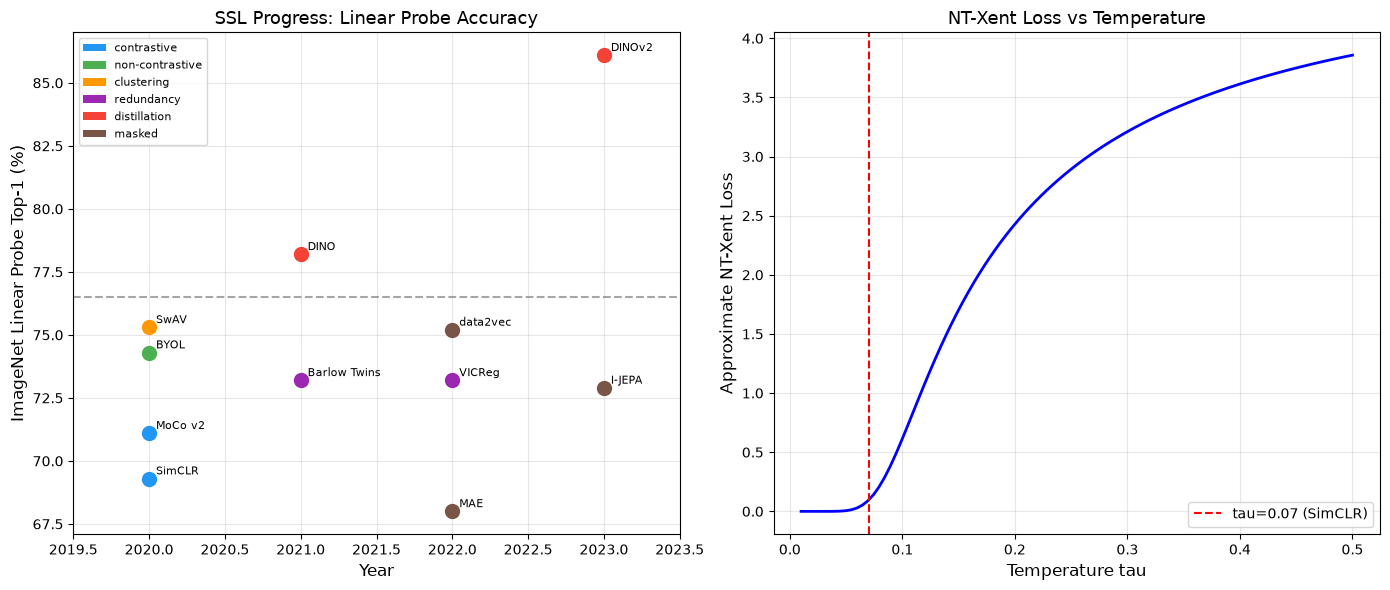

In [16]:
# Comparison visualization: SSL methods timeline and performance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: ImageNet linear probe accuracy over time ---
methods = [
    ('SimCLR', 2020, 69.3, 'contrastive'),
    ('MoCo v2', 2020, 71.1, 'contrastive'),
    ('BYOL', 2020, 74.3, 'non-contrastive'),
    ('SwAV', 2020, 75.3, 'clustering'),
    ('Barlow Twins', 2021, 73.2, 'redundancy'),
    ('DINO', 2021, 78.2, 'distillation'),
    ('VICReg', 2022, 73.2, 'redundancy'),
    ('MAE', 2022, 68.0, 'masked'),
    ('data2vec', 2022, 75.2, 'masked'),
    ('DINOv2', 2023, 86.1, 'distillation'),
    ('I-JEPA', 2023, 72.9, 'masked'),
]

colors = {
    'contrastive': '#2196F3',
    'non-contrastive': '#4CAF50',
    'clustering': '#FF9800',
    'redundancy': '#9C27B0',
    'distillation': '#F44336',
    'masked': '#795548'
}

for name, year, acc, category in methods:
    axes[0].scatter(year, acc, color=colors[category], s=100, zorder=5)
    axes[0].annotate(name, (year, acc), textcoords='offset points',
                     xytext=(5, 3), fontsize=8)

# Add supervised baseline
axes[0].axhline(y=76.5, color='gray', linestyle='--', alpha=0.7, label='Supervised ResNet-50')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('ImageNet Linear Probe Top-1 (%)', fontsize=12)
axes[0].set_title('SSL Progress: Linear Probe Accuracy', fontsize=13)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(2019.5, 2023.5)

# Legend for categories
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=k) for k, c in colors.items()]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=8)

# --- Plot 2: NT-Xent loss landscape as function of temperature ---
temperatures = np.linspace(0.01, 0.5, 100)
N = 64
losses = []

for tau in temperatures:
    # Approximate: avg loss for random negatives
    # Positive similarity ~ 0.5 (good), negative similarity ~ 0 (random)
    pos_sim = 0.5 / tau
    neg_sims = np.zeros(2 * N - 2)
    log_denom = np.log(np.exp(pos_sim) + np.sum(np.exp(neg_sims / tau)))
    loss = -(pos_sim - log_denom)
    losses.append(loss)

axes[1].plot(temperatures, losses, 'b-', linewidth=2)
axes[1].axvline(x=0.07, color='r', linestyle='--', label='tau=0.07 (SimCLR)')
axes[1].set_xlabel('Temperature tau', fontsize=12)
axes[1].set_ylabel('Approximate NT-Xent Loss', fontsize=12)
axes[1].set_title('NT-Xent Loss vs Temperature', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/ssl_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

Training SimCLR on synthetic data...


  Epoch  5/20 | Loss: 2.5363


  Epoch 10/20 | Loss: 2.5575


  Epoch 15/20 | Loss: 2.5325


  Epoch 20/20 | Loss: 2.5396
Training complete!


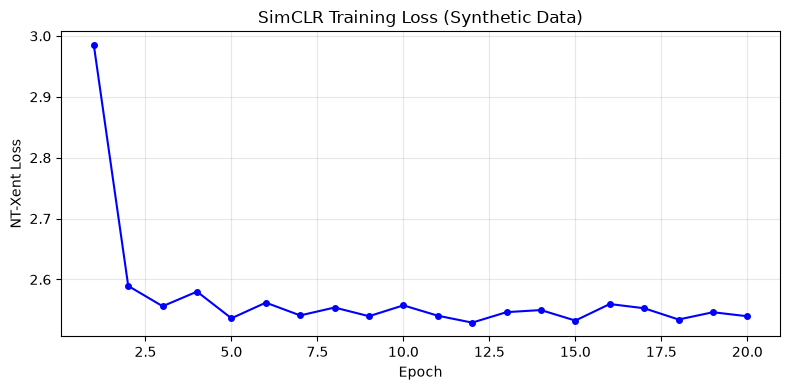

In [17]:
# Full mini-training demo: SimCLR on synthetic data
import random

class SyntheticPairedDataset(Dataset):
    """Synthetic dataset: each sample is a pair of augmented views."""

    def __init__(self, n_samples=512, img_size=32, n_classes=10):
        self.n_samples = n_samples
        self.img_size = img_size
        # Each class gets a distinct mean color
        self.class_means = torch.randn(n_classes, 3, 1, 1) * 0.5
        self.labels = torch.randint(0, n_classes, (n_samples,))

    def __len__(self):
        return self.n_samples

    def _augment(self, base):
        """Add noise as a proxy for augmentation."""
        return base + torch.randn_like(base) * 0.3

    def __getitem__(self, idx):
        label = self.labels[idx]
        base = self.class_means[label].expand(3, self.img_size, self.img_size).clone()
        view1 = self._augment(base)
        view2 = self._augment(base)
        return view1, view2, label


# Training configuration
dataset = SyntheticPairedDataset(n_samples=512)
loader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=True)

simclr_model = SimCLR(out_dim=64).to(device)
optimizer = torch.optim.Adam(simclr_model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = NTXentLoss(temperature=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

print('Training SimCLR on synthetic data...')
history = []

for epoch in range(20):
    epoch_loss = 0.0
    for v1, v2, _ in loader:
        v1, v2 = v1.to(device), v2.to(device)
        _, z1 = simclr_model(v1)
        _, z2 = simclr_model(v2)
        loss = loss_fn(z1, z2)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    avg_loss = epoch_loss / len(loader)
    history.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f'  Epoch {epoch+1:2d}/20 | Loss: {avg_loss:.4f}')

print('Training complete!')

# Plot training curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 21), history, 'b-o', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('NT-Xent Loss')
plt.title('SimCLR Training Loss (Synthetic Data)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/simclr_training.png', dpi=100, bbox_inches='tight')
plt.show()

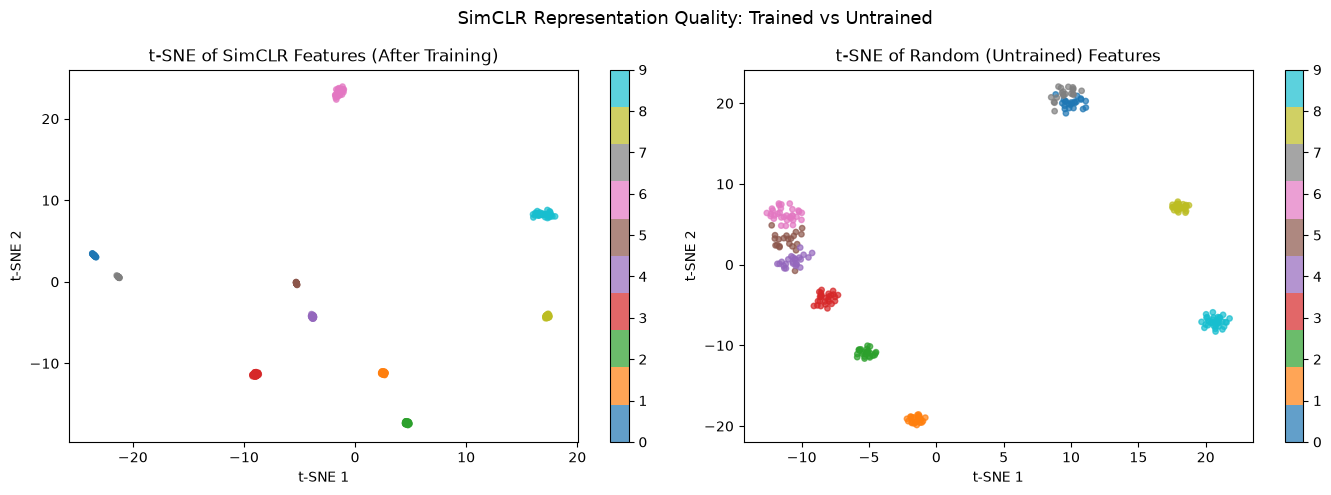

In [18]:
# Visualize learned representations with t-SNE
from sklearn.manifold import TSNE

def extract_features(model, dataset, device, n_samples=256):
    """Extract encoder features for visualization."""
    model.eval()
    loader = DataLoader(dataset, batch_size=64, shuffle=False)
    features, labels = [], []

    with torch.no_grad():
        for v1, _, y in loader:
            h, _ = model(v1.to(device))
            features.append(h.cpu())
            labels.append(y)
            if len(features) * 64 >= n_samples:
                break

    features = torch.cat(features)[:n_samples].numpy()
    labels = torch.cat(labels)[:n_samples].numpy()
    return features, labels


# Extract features from trained SimCLR
features, labels = extract_features(simclr_model, dataset, device)

# Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(features)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels,
                           cmap='tab10', s=15, alpha=0.7)
plt.colorbar(scatter, ax=axes[0])
axes[0].set_title('t-SNE of SimCLR Features (After Training)', fontsize=12)
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

# Random (untrained) features for comparison
untrained_model = SimCLR(out_dim=64).to(device)
rand_features, rand_labels = extract_features(untrained_model, dataset, device)
rand_2d = tsne.fit_transform(rand_features)

scatter2 = axes[1].scatter(rand_2d[:, 0], rand_2d[:, 1], c=rand_labels,
                            cmap='tab10', s=15, alpha=0.7)
plt.colorbar(scatter2, ax=axes[1])
axes[1].set_title('t-SNE of Random (Untrained) Features', fontsize=12)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.suptitle('SimCLR Representation Quality: Trained vs Untrained', fontsize=13)
plt.tight_layout()
plt.savefig('/tmp/tsne_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Using Pre-Trained MAE from HuggingFace

HuggingFace provides pre-trained MAE models for direct use.

In [19]:
# MAE via HuggingFace commented out to avoid download
# Uncomment to run with internet access.

# from transformers import AutoFeatureExtractor, ViTMAEModel, ViTMAEForPreTraining
# from PIL import Image
# import requests

# # Load MAE pre-trained model
# model_name = 'facebook/vit-mae-base'
# feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)
# mae_model = ViTMAEForPreTraining.from_pretrained(model_name)

# # Load a sample image
# url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
# image = Image.open(requests.get(url, stream=True).raw)

# # Preprocess and run MAE
# inputs = feature_extractor(images=image, return_tensors='pt')
# with torch.no_grad():
#     outputs = mae_model(**inputs)
#
# print(f'MAE reconstruction loss: {outputs.loss.item():.4f}')
# print(f'Logits shape (reconstructed patches): {outputs.logits.shape}')

# # Extract encoder features only (for downstream tasks)
# encoder_model = ViTMAEModel.from_pretrained(model_name)
# with torch.no_grad():
#     enc_outputs = encoder_model(**inputs)
# print(f'Encoder output shape: {enc_outputs.last_hidden_state.shape}')

print('MAE HuggingFace code ready (commented out to avoid download).')
print('Available MAE variants on HuggingFace:')
for v in ['vit-mae-base', 'vit-mae-large', 'vit-mae-huge']:
    print(f'  facebook/{v}')

MAE HuggingFace code ready (commented out to avoid download).
Available MAE variants on HuggingFace:
  facebook/vit-mae-base
  facebook/vit-mae-large
  facebook/vit-mae-huge


## 8. Practical Considerations

### 8.1 Choosing the Right SSL Method

| Scenario | Recommended Method |
|----------|--------------------|
| Limited GPU memory | SimCLR (small batch) + MoCo queue trick |
| Vision tasks, few labels | DINOv2 or MAE pre-training |
| Multi-modal (vision + text) | CLIP (contrastive cross-modal) |
| NLP tasks | BERT/RoBERTa masked modeling |
| Speech/audio | wav2vec 2.0, HuBERT |
| Best off-the-shelf features | DINOv2-ViT-L/14 |
| Training from scratch (compute budget) | MAE (75% masking, fast) |

### 8.2 Implementation Tips

1. **Augmentation strength matters** too weak: trivial representations; too strong: harder optimization
2. **Learning rate scaling** use linear scaling rule: $\text{lr} = 0.3 \times \frac{\text{batch\_size}}{256}$
3. **Warmup** cosine schedule with 10-epoch warmup stabilizes contrastive training
4. **Projection head** always use a 2-3 layer MLP; discard it for downstream tasks
5. **Batch normalization** avoid BN in the online/target path for SimSiam/BYOL to prevent information leakage
6. **MAE masking** 75% mask ratio is surprisingly optimal; too low reduces task difficulty

### 8.3 Common Pitfalls

- **Mode collapse**: All embeddings map to the same point. Diagnosed by monitoring the **std of embeddings** per dimension (should be > 0).
- **Representation collapse** (SimSiam): Predictions become constant. Monitor the **cosine similarity** between $p$ and $\text{sg}(z)$ should be close to $-1$ not $+1$.
- **Insufficient negatives**: With SimCLR, batch size < 256 gives poor results. Use MoCo for small GPU memory.
- **Temperature sensitivity**: Very small $\tau$ concentrates the distribution too sharply; very large $\tau$ makes the loss uniform and uninformative.

In [20]:
def monitor_representations(model, dataloader, device, n_batches=5):
    """
    Monitor representation health during SSL training.
    Checks for collapse by measuring:
    1. Per-dimension std (should be > 0.01)
    2. Average cosine similarity between random pairs (should be near 0)
    3. Rank of feature matrix (should be close to feature_dim)
    """
    model.eval()
    all_feats = []

    with torch.no_grad():
        for i, (v1, v2, _) in enumerate(dataloader):
            h, _ = model(v1.to(device))
            all_feats.append(h.cpu())
            if i >= n_batches:
                break

    feats = torch.cat(all_feats)  # (N, D)

    # Per-dimension std
    std_per_dim = feats.std(dim=0)
    avg_std = std_per_dim.mean().item()
    min_std = std_per_dim.min().item()

    # Average cosine similarity between random pairs
    feats_norm = F.normalize(feats, dim=1)
    n = min(len(feats), 100)
    idx = torch.randperm(len(feats))[:n]
    sims = torch.mm(feats_norm[idx], feats_norm[idx].T)
    # Exclude self-similarity
    mask = ~torch.eye(n, dtype=torch.bool)
    avg_sim = sims[mask].mean().item()

    print(f'Representation Health Metrics:')
    print(f'  Avg std per dimension: {avg_std:.4f} (collapse if < 0.01)')
    print(f'  Min std per dimension: {min_std:.4f}')
    print(f'  Avg pairwise cosine similarity: {avg_sim:.4f} (collapse if -> 1.0)')

    collapsed = (avg_std < 0.01) or (avg_sim > 0.99)
    status = 'COLLAPSED!' if collapsed else 'healthy'
    print(f'  Status: {status}')
    return avg_std, avg_sim


# Monitor the trained SimCLR model
print('Monitoring trained SimCLR representations:')
monitor_representations(simclr_model, loader, device)

Monitoring trained SimCLR representations:


Representation Health Metrics:
  Avg std per dimension: 1.1478 (collapse if < 0.01)
  Min std per dimension: 0.3535
  Avg pairwise cosine similarity: 0.4085 (collapse if -> 1.0)
  Status: healthy


(1.1478147506713867, 0.4084723889827728)

## 9. Summary and Key Takeaways

### The SSL Landscape

Self-supervised learning has evolved rapidly:

1. **Contrastive era (2020)**: SimCLR, MoCo require negatives, batch-size sensitive
2. **Negative-free era (2020-2021)**: BYOL, SimSiam stop-gradient/EMA prevents collapse
3. **Redundancy reduction (2021)**: Barlow Twins, VICReg feature decorrelation
4. **Clustering (2020-2021)**: SwAV prototype-based online clustering
5. **Masked modeling (2021-2023)**: MAE, BEiT, data2vec prediction in pixel/token/latent space
6. **Distillation (2021-2023)**: DINO, DINOv2 teacher-student self-distillation at scale

### Core Principles Across All Methods

| Principle | Purpose |
|-----------|--------|
| View invariance | Learn features robust to augmentations |
| Collapse prevention | Avoid trivial constant representations |
| Asymmetry | Stop-gradient / EMA / momentum encoder |
| Strong augmentations | Force semantic feature learning |
| Large-scale training | SSL benefits enormously from more data |

### When Does SSL Beat Supervised Pre-Training?

- When labeled data is scarce (semi-supervised regime)
- When domain shift is large (SSL generalizes better)
- When the downstream task requires dense/local features (MAE, DINO patches)
- At very large scale: DINOv2 ViT-L outperforms supervised pre-training on most vision tasks

## Additional Learning Resources

### Foundational Papers

**Contrastive Methods:**
- **SimCLR**: Chen et al. (2020). *A Simple Framework for Contrastive Learning of Visual Representations*. https://arxiv.org/abs/2002.05709
- **MoCo**: He et al. (2020). *Momentum Contrast for Unsupervised Visual Representation Learning*. https://arxiv.org/abs/1911.05722
- **MoCo v2**: Chen et al. (2020). *Improved Baselines with Momentum Contrastive Learning*. https://arxiv.org/abs/2003.04297
- **BYOL**: Grill et al. (2020). *Bootstrap Your Own Latent: A New Approach to Self-Supervised Learning*. https://arxiv.org/abs/2006.07733
- **SimSiam**: Chen & He (2021). *Exploring Simple Siamese Representation Learning*. https://arxiv.org/abs/2011.10566

**Non-Contrastive / Redundancy Reduction:**
- **Barlow Twins**: Zbontar et al. (2021). *Barlow Twins: Self-Supervised Learning via Redundancy Reduction*. https://arxiv.org/abs/2103.03230
- **VICReg**: Bardes et al. (2022). *VICReg: Variance-Invariance-Covariance Regularization for Self-Supervised Learning*. https://arxiv.org/abs/2105.04906

**Clustering:**
- **SwAV**: Caron et al. (2020). *Unsupervised Learning of Visual Features by Contrasting Cluster Assignments*. https://arxiv.org/abs/2006.09882
- **DeepCluster**: Caron et al. (2018). *Deep Clustering for Unsupervised Learning of Visual Features*. https://arxiv.org/abs/1807.05520

**Masked Modeling:**
- **BERT**: Devlin et al. (2018). *BERT: Pre-training of Deep Bidirectional Transformers*. https://arxiv.org/abs/1810.04805
- **MAE**: He et al. (2022). *Masked Autoencoders Are Scalable Vision Learners*. https://arxiv.org/abs/2111.06377
- **BEiT**: Bao et al. (2022). *BEiT: BERT Pre-Training of Image Transformers*. https://arxiv.org/abs/2106.08254
- **data2vec**: Baevski et al. (2022). *data2vec: A General Framework for Self-supervised Learning in Speech, Vision and Language*. https://arxiv.org/abs/2202.03555
- **I-JEPA**: Assran et al. (2023). *Self-Supervised Learning from Images with a Joint-Embedding Predictive Architecture*. https://arxiv.org/abs/2301.08243
- **iBOT**: Zhou et al. (2021). *iBOT: Image BERT Pre-Training with Online Tokenizer*. https://arxiv.org/abs/2111.07832

**Distillation-Based:**
- **DINO**: Caron et al. (2021). *Emerging Properties in Self-Supervised Vision Transformers*. https://arxiv.org/abs/2104.14294
- **DINOv2**: Oquab et al. (2023). *DINOv2: Learning Robust Visual Features without Supervision*. https://arxiv.org/abs/2304.07193

### Courses and Tutorials

- **Stanford CS224N** (NLP / BERT): https://web.stanford.edu/class/cs224n/
- **Yann LeCun's Self-Supervised Learning Talk** (NYU): https://www.youtube.com/watch?v=8L10w1KoOU8
- **Lilian Weng's SSL Blog Post**: https://lilianweng.github.io/posts/2021-05-31-contrastive/
- **PyTorch SSL Tutorial (lightly-ai)**: https://docs.lightly.ai/self-supervised-learning/getting_started/benchmarks.html
- **HuggingFace Course**: https://huggingface.co/course

### Code Repositories

- **lightly**: Clean PyTorch SSL library https://github.com/lightly-ai/lightly
- **VISSL** (Facebook): https://github.com/facebookresearch/vissl
- **solo-learn**: Multiple SSL methods in one repo https://github.com/vturrisi/solo-learn
- **MAE official**: https://github.com/facebookresearch/mae
- **DINO official**: https://github.com/facebookresearch/dino
- **DINOv2 official**: https://github.com/facebookresearch/dinov2

### Benchmarks and Leaderboards

- **Papers with Code SSL on ImageNet**: https://paperswithcode.com/task/self-supervised-image-classification
- **SSL Benchmark Suite**: https://github.com/KordingLab/ssl-benchmark